# Walkthrough — Few-Step Image Generation, visualized

**Research question.** How does image quality (FID) depend on the *number of sampling
steps* for **Flow Matching / Rectified Flow** vs. a **DDPM** baseline — and can *reflow*
push generation to even fewer steps?

This notebook is the visual tour. It loads the trained models and shows, inline:

1. Flow Matching samples as the step count grows (1 → 16 steps)
2. The **sampling trajectory** — how an image forms, noise → digit, step by step
3. **Flow vs. DDPM head-to-head** in the few-step regime (the core comparison)
4. The effect of classifier-free guidance
5. **Reflow** at 1–2 steps
6. **Domain shift**: the same story on Fashion-MNIST (clothing)
7. A recap of the quantitative FID-vs-steps results

It runs locally (from the repo root, with trained checkpoints under `results/`) or on
Kaggle. For the full training + FID sweep see `02_results.ipynb`.

## Setup

In [1]:
import os, sys, subprocess
# Work from the repo root so `import fmfs` and the results/ paths resolve.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
try:
    import fmfs  # noqa: F401
except ModuleNotFoundError:
    if not os.path.isdir('flow-matching-fewstep'):
        subprocess.run(['git', 'clone', '-q', 'https://github.com/xHansi/flow-matching-fewstep.git'])
        subprocess.run(['pip', 'install', '-q', 'pytorch-fid'])
    os.chdir('flow-matching-fewstep')
    sys.path.insert(0, os.getcwd())
    import fmfs  # noqa: F401
print('working dir:', os.getcwd())

working dir: /Users/hansi/PycharmProjects/appliedAi/homework/flow-matching-fewstep


In [2]:
import torch
from pathlib import Path
from IPython.display import Image, display
from fmfs.flow import make_method
from fmfs.inference import load_checkpoint
from fmfs.utils import get_device, save_samples, save_trajectory, set_seed

device = get_device()
os.makedirs('demo_out', exist_ok=True)
print('device:', device)

def show(imgs, name, nrow=10):
    p = f'demo_out/{name}.png'; save_samples(imgs, p, nrow=nrow); display(Image(p))

def show_traj(traj, name):
    p = f'demo_out/{name}.png'; save_trajectory(traj, p); display(Image(p))

device: mps


### Load the trained models

Checkpoints are self-describing (they store their architecture), so one loader handles
flow, ddpm and reflow. If a checkpoint is missing, train it first with
`python -m scripts.train --method <flow|ddpm> --dataset <mnist|fashion>`.

In [3]:
def try_load(path):
    return load_checkpoint(path, device) if Path(path).exists() else (None, None, None)

flow_m, flow, _   = try_load('results/flow_mnist/ckpt.pt')
ddpm_m, ddpm, _   = try_load('results/ddpm_mnist/ckpt.pt')
reflow_m, reflow, _ = try_load('results/reflow_mnist/ckpt.pt')
flow_f, flowf, _  = try_load('results/flow_fashion/ckpt.pt')
ddpm_f, ddpmf, _  = try_load('results/ddpm_fashion/ckpt.pt')
print('loaded:', [n for n, m in [('flow',flow_m),('ddpm',ddpm_m),('reflow',reflow_m),('flow_fashion',flow_f),('ddpm_fashion',ddpm_f)] if m is not None])

loaded: ['flow', 'ddpm', 'reflow', 'flow_fashion', 'ddpm_fashion']


## 1. Flow Matching: samples vs. number of steps

Each column is a digit class (0–9). The only thing that changes across the grids below is
the number of Euler steps used to integrate the sampling ODE. Even at **1–2 steps** the
digits are already recognizable, and by ~8 steps they are clean — this is the core promise
of Flow Matching.

Flow Matching — 1 sampling step(s)


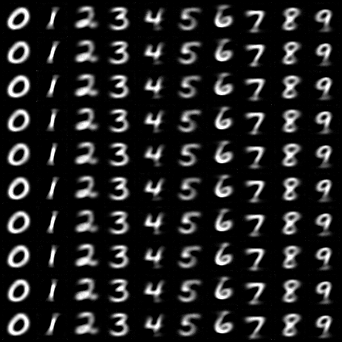

Flow Matching — 2 sampling step(s)


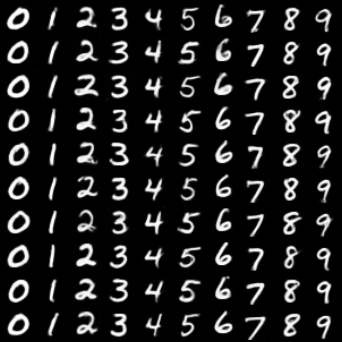

Flow Matching — 4 sampling step(s)


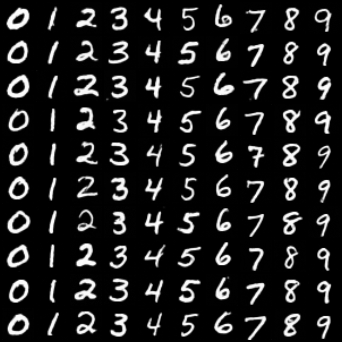

Flow Matching — 8 sampling step(s)


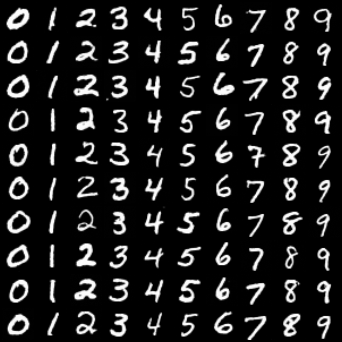

Flow Matching — 16 sampling step(s)


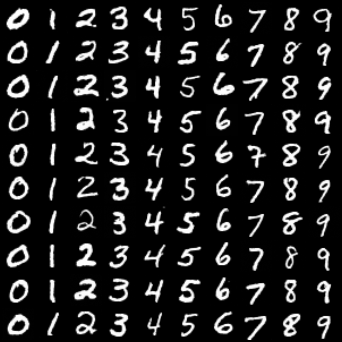

In [4]:
y = torch.arange(10, device=device).repeat(10)
for s in (1, 2, 4, 8, 16):
    print(f'Flow Matching — {s} sampling step(s)')
    set_seed(0); show(flow.sample(flow_m, y, steps=s, cfg_scale=2.0), f'flow_{s}')

## 2. The sampling trajectory (noise → digit)

Here we open up a single generation. Each **row** is one digit; the columns go left→right
from pure Gaussian noise to the finished image. This is literally the ODE being integrated
one Euler step at a time — the straight-line paths of Rectified Flow are what make so few
steps possible.

8 steps  (9 columns: noise -> digit)


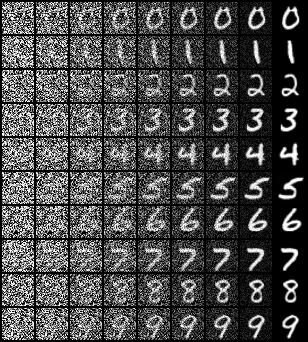

16 steps (finer integration)


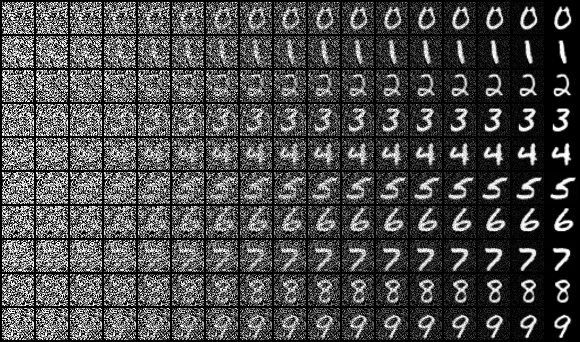

In [5]:
y = torch.arange(10, device=device)
set_seed(3); _, t8 = flow.sample(flow_m, y, steps=8, cfg_scale=2.0, return_trajectory=True)
print('8 steps  (9 columns: noise -> digit)'); show_traj(t8, 'traj8')
set_seed(3); _, t16 = flow.sample(flow_m, y, steps=16, cfg_scale=2.0, return_trajectory=True)
print('16 steps (finer integration)'); show_traj(t16, 'traj16')

## 3. Flow Matching vs. DDPM — the few-step regime

This is the heart of the project. Same step budget, same guidance — Flow Matching (top)
vs. the DDPM baseline (bottom). At **2 steps** Flow already gives readable digits while
DDPM is essentially noise; by 8 steps DDPM has mostly caught up. This is exactly the
behaviour the FID-vs-steps curves quantify.

=== 2 steps ===
Flow Matching:


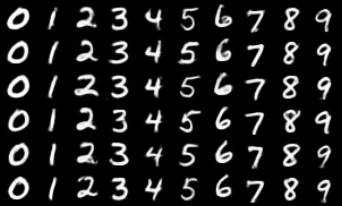

DDPM (DDIM):


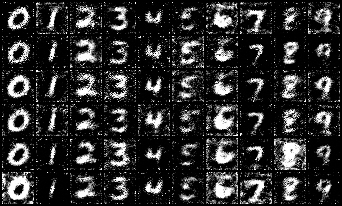

=== 8 steps ===
Flow Matching:


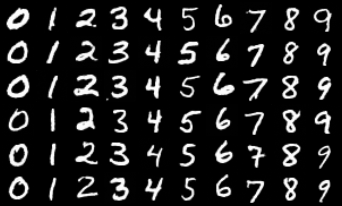

DDPM (DDIM):


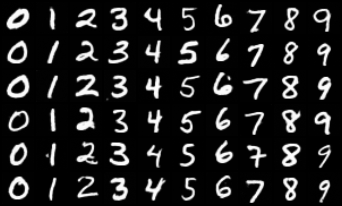

In [6]:
y = torch.arange(10, device=device).repeat(6)
for s in (2, 8):
    print(f'=== {s} steps ===')
    print('Flow Matching:'); set_seed(0); show(flow.sample(flow_m, y, steps=s, cfg_scale=2.0), f'cmp_flow_{s}')
    print('DDPM (DDIM):');   set_seed(0); show(ddpm.sample(ddpm_m, y, steps=s, cfg_scale=2.0, eta=0.0), f'cmp_ddpm_{s}')

## 4. Classifier-free guidance

Guidance (`cfg_scale`) trades diversity for class fidelity. Higher values make the class
clearer but can over-saturate. Because guidance also interacts with step count, the
**FID numbers are measured without guidance** (`cfg=1.0`); guidance is only used to make
these qualitative grids look crisp.

guidance = 1.0


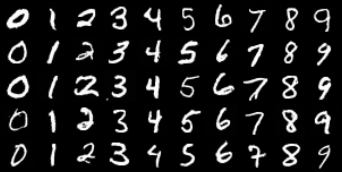

guidance = 2.0


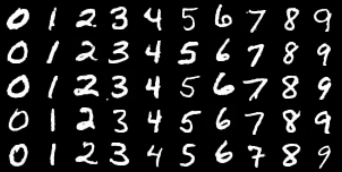

guidance = 3.0


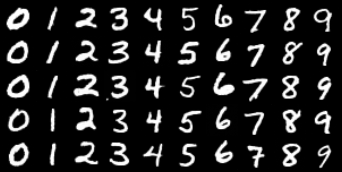

In [7]:
y = torch.arange(10, device=device).repeat(5)
for w in (1.0, 2.0, 3.0):
    print(f'guidance = {w}'); set_seed(0); show(flow.sample(flow_m, y, steps=8, cfg_scale=w), f'cfg_{w}')

## 5. Reflow — straightening the paths

Reflow retrains the flow model on its own `(noise, sample)` pairs, which straightens the
ODE trajectories. The payoff shows up at the extreme low end (1–2 steps), where the
straighter paths land on the right class almost immediately.

Reflow — 1 step(s)


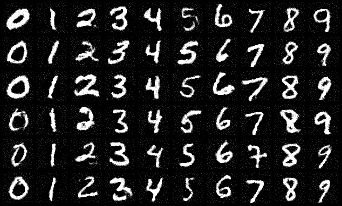

Reflow — 2 step(s)


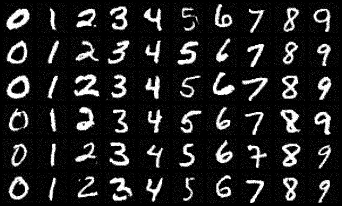

Reflow — 4 step(s)


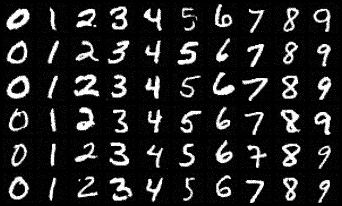

In [8]:
if reflow_m is not None:
    y = torch.arange(10, device=device).repeat(6)
    for s in (1, 2, 4):
        print(f'Reflow — {s} step(s)'); set_seed(0); show(reflow.sample(reflow_m, y, steps=s, cfg_scale=2.0), f'reflow_{s}')
else:
    print('No reflow checkpoint; run scripts/reflow.py first.')

## 6. Domain shift — Fashion-MNIST

Does the few-step advantage survive a change of domain? We ran the identical pipeline on
**Fashion-MNIST** (clothing — a harder, more textured domain). Below: Flow vs. DDPM at 2
steps on clothing. The qualitative story is the same as on digits — Flow is already
coherent while DDPM is still noise.

Fashion — Flow Matching, 2 steps:


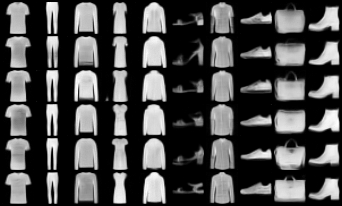

Fashion — Flow Matching, 8 steps:


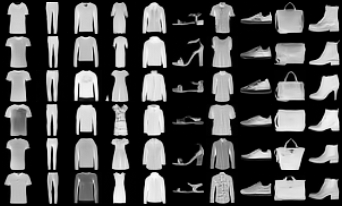

Fashion — DDPM, 2 steps:


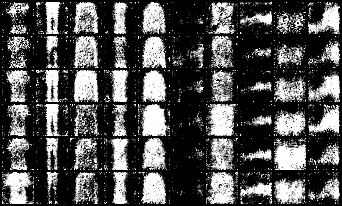

In [9]:
if flow_f is not None:
    y = torch.arange(10, device=device).repeat(6)
    print('Fashion — Flow Matching, 2 steps:'); set_seed(0); show(flowf.sample(flow_f, y, steps=2, cfg_scale=2.0), 'fash_flow_2')
    print('Fashion — Flow Matching, 8 steps:'); set_seed(0); show(flowf.sample(flow_f, y, steps=8, cfg_scale=2.0), 'fash_flow_8')
    if ddpm_f is not None:
        print('Fashion — DDPM, 2 steps:'); set_seed(0); show(ddpmf.sample(ddpm_f, y, steps=2, cfg_scale=2.0, eta=0.0), 'fash_ddpm_2')
else:
    print('No fashion checkpoint; train with --dataset fashion.')

## 7. Quantitative recap — FID vs. steps

The grids above are qualitative; the FID sweep (`02_results.ipynb` / `scripts/eval_fid.py`)
makes it precise. Committed results are in `figures/`. Below we print the InceptionV3-FID
table straight from the saved JSON.

In [10]:
import json
for name, path in [('MNIST', 'figures/mnist/fid.json'), ('Fashion-MNIST', 'figures/fashion/fid.json')]:
    if not Path(path).exists():
        continue
    d = json.load(open(path))['inception']
    steps = [1, 2, 4, 8, 16, 50, 100]
    print(f'\n=== {name} — InceptionV3-FID (lower is better) ===')
    print('steps :', '  '.join(f'{s:>6}' for s in steps))
    for m in ('flow', 'ddpm', 'reflow'):
        if m in d:
            print(f'{m:6s}:', '  '.join(f'{d[m][str(s)]:6.1f}' for s in steps))


=== MNIST — InceptionV3-FID (lower is better) ===
steps :      1       2       4       8      16      50     100
flow  :  191.3    25.9    12.9     8.4     7.1     6.9     7.0
ddpm  :  418.6   255.5    27.6    13.7     9.0     7.8     8.4
reflow:   23.4    10.0     8.7     8.4     8.2     8.1     8.0

=== Fashion-MNIST — InceptionV3-FID (lower is better) ===
steps :      1       2       4       8      16      50     100
flow  :  227.5    50.7    26.4    19.2    15.7    13.3    13.0
ddpm  :  402.5   262.9    43.9    20.9    16.1    13.5    13.2
reflow:   20.2    15.6    15.1    14.8    14.8    14.8    14.8


**Reading the tables.** On both domains Flow Matching is far ahead of DDPM at 1–4 steps
and they converge once many steps are used. The full plots (both metrics, both domains,
and the side-by-side domain comparison) are in `figures/` and discussed in
`report/REPORT.md`.

![domain comparison](../figures/comparison/fid_vs_steps_inception.png)

---
### Takeaways

- **Flow Matching wins in the few-step regime** — recognizable images at 2 steps, clean by
  ~8; DDPM needs many more steps.
- **Reflow** helps most at 1–2 steps by straightening the sampling paths.
- **The advantage is robust to a domain shift** (digits → clothing), though the gap narrows
  and absolute quality drops on the harder domain.

See `02_results.ipynb` to reproduce the training and the full FID sweep end to end.